# Converting Received Audio to a Binary Sequence

Last semester, I analyzed CW audio samples using FFT, or Fast Fourier Transforms. FFT effectively transforms an __entire__ audio sample into frequency bins. In contrast, _Goertzel's algorithm_ transforms a __selected frequency__. In this sense, it's more efficient.

In terms of Big $O$:

**FFT**: $O(n \log n)$

**Gortzel**: $O(m * n)$, where $m = \text{frequency}$

So, for our CW code sent on a single $700 \text{ Hz}$ carrier, $m \approxeq 1$

## Understandig Goertzel's algorithm

### Step 1 - Calculate Frequency
$\omega_k = \frac{2 \pi k}{N}$

### Apply the recursive algorithm
$S(n) - x(n) + 2 \cos(\omega_k) * S(n-1) - S(n-2)$

Where the _initial conditions_ are:
$$ S(-1) = S(-2) = 0 $$

### DFT of the $k^{th}$ sample

$\implies X(k) = e^{-j \omega_k} * S(n-1) - S(n-2)$

In [1]:
import numpy as np

def goertzel_power(samples, sample_rate, target_freq):
    n = len(samples)
    k = int(0.5 + (n * target_freq) / sample_rate)
    omega = (2.0 * np.pi * k) / n
    coeff = 2.0 * np.cos(omega)
    
    s0, s1, s2 = 0.0, 0.0, 0.0
    for sample in samples:
        s0 = sample + coeff * s1 - s2
        s2 = s1
        s1 = s0
        
    power = s1**2 + s2**2 - coeff * s1 * s2
    return power

def extract_envelope(audio, sample_rate, target_freq, frame_size=256, hop_size=128):
    powers = []
    for start in range(0, len(audio) - frame_size, hop_size):
        frame = audio[start : start + frame_size]
        powers.append(goertzel_power(frame, sample_rate, target_freq))
    
    env = np.array(powers)
    # Normalize envelope to [0, 1]
    env = (env - env.min()) / (env.max() - env.min() + 1e-9)
    return env

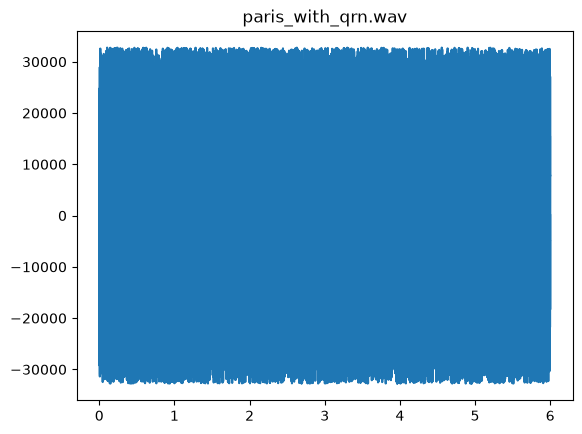

In [8]:
from scipy.io import wavfile

audio = "paris_with_qrn.wav"
sample_rate, samples = wavfile.read(audio)

import matplotlib.pyplot as plt

t_values = np.arange(len(samples)) / sample_rate

fig, ax = plt.subplots()

ax.plot(t_values, samples)
plt.title("paris_with_qrn.wav")
plt.style.use("fivethirtyeight")
plt.show()

In [ ]:
from IPython.display import Audio, display

display(Audio(audio))

> Clearly, this is a very noisy sample, visually from the amplitude and directly by listening to it...

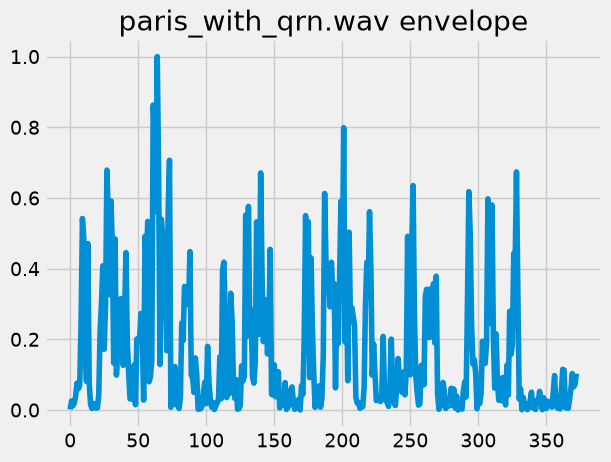

In [16]:
envelope = extract_envelope(samples, sample_rate, target_freq=700)

t_values = np.arange(len(envelope))

fig, ax = plt.subplots()

ax.plot(t_values, envelope)
plt.title("paris_with_qrn.wav envelope")
plt.style.use("fivethirtyeight")
plt.show()

Here, you can just barely make out the sequence with a bit of imagination. P-A-R-I-S.

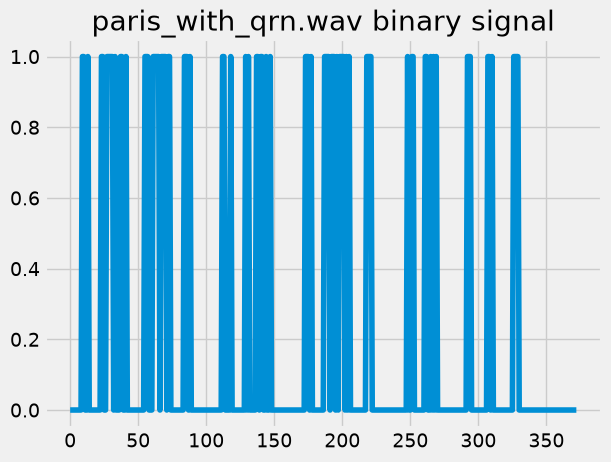

In [32]:
binary_signal = (envelope > 0.30).astype(int)

fig, ax = plt.subplots()

ax.plot(t_values, binary_signal)
plt.title("paris_with_qrn.wav binary signal")
plt.style.use("fivethirtyeight")
plt.show()

# Developing a Decoder

Let's back up again and try working with a pure signal, no noise or weirdness.

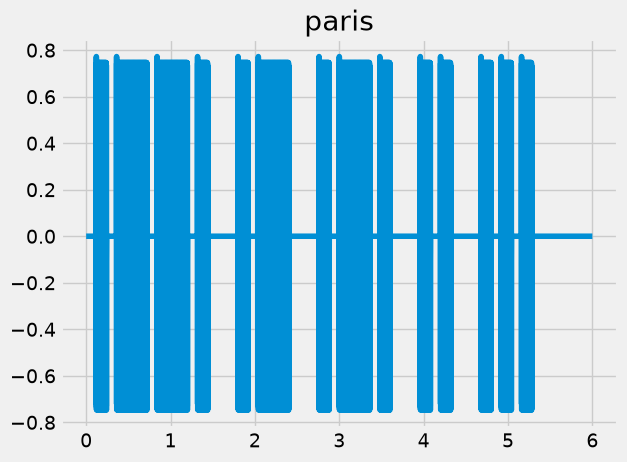

In [44]:
import sys
from pathlib import Path

# Add project root directory to sys.path
root_dir = Path.cwd().parent
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

from cw.signal import generate_audio
samples = generate_audio(message = "paris",
    wpm = 10,
    frequency = 700,
    sample_rate = 8000)

t_values = np.arange(len(samples)) / sample_rate

fig, ax = plt.subplots()

ax.plot(t_values, samples)
plt.title("paris")
plt.style.use("fivethirtyeight")
plt.show()

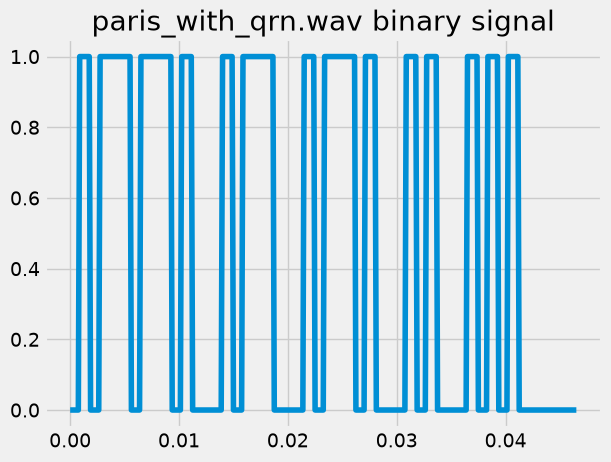

In [46]:
envelope = extract_envelope(samples, sample_rate, target_freq=700)

binary_signal = (envelope > 0.30).astype(int)

t_values = np.arange(len(binary_signal)) / sample_rate

fig, ax = plt.subplots()

ax.plot(t_values, binary_signal)
plt.title("paris_with_qrn.wav binary signal")
plt.style.use("fivethirtyeight")
plt.show()

In [47]:
import itertools
import numpy as np

# 1. Compress binary_signal into (state, duration) pairs
runs = [(val, sum(1 for _ in group)) for val, group in itertools.groupby(binary_signal)]

# 2. Extract durations ONLY where the tone was ON (val == 1)
mark_lengths = [duration for val, duration in runs if val == 1]

# 3. Scikit-learn requires a 2D array of shape (n_samples, n_features)
mark_durations = np.array(mark_lengths).reshape(-1, 1)

In [48]:
from sklearn.mixture import GaussianMixture

# marks is a 2D array of pulse lengths: shape (n_marks, 1)
gmm_marks = GaussianMixture(n_components=2).fit(mark_durations)
# Cluster with the smaller mean is 'dot', larger is 'dash'
dot_idx = np.argmin(gmm_marks.means_)
labels = gmm_marks.predict(mark_durations)

In [ ]:
print(labels)

array([0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0])

Though cryptic, this actually has the essence of the information:

0110: P
01: A
010: R
00: I
000: S

The problem is, this grouping only distinguishes groups of dots and dashes. We need a bit more grouping in order to distinguish the spaces so that we can tell characters from words, etc.

In [63]:
import itertools
import numpy as np
from sklearn.mixture import GaussianMixture

# --- 1. RLE Compression ---
# Preserves both marks (1) and spaces (0) in time order
runs = [(val, sum(1 for _ in g)) for val, g in itertools.groupby(binary_signal)]

# Strip leading and trailing silence
if runs and runs[0][0] == 0:
    runs.pop(0)
if runs and runs[-1][0] == 0:
    runs.pop(-1)

# --- 2. Fit Marks with GMM ---
mark_lengths = [dur for state, dur in runs if state == 1]
mark_durations = np.array(mark_lengths).reshape(-1, 1)

gmm_marks = GaussianMixture(n_components=2, random_state=42).fit(mark_durations)

# Identify which cluster index is dot (smaller mean) vs dash (larger mean)
dot_cluster = int(np.argmin(gmm_marks.means_))
dot_len = float(np.min(gmm_marks.means_))

# Space thresholds calibrated directly against the discovered dot length
char_space_thresh = 2.0 * dot_len   # Boundary between intra-char and inter-char gap
word_space_thresh = 5.0 * dot_len   # Boundary between inter-char and word gap

# --- 3. Morse Dictionary ---
MORSE_TABLE = {
    '.-': 'A', '-...': 'B', '-.-.': 'C', '-..': 'D', '.': 'E',
    '..-.': 'F', '--.': 'G', '....': 'H', '..': 'I', '.---': 'J',
    '-.-': 'K', '.-..': 'L', '--': 'M', '-.': 'N', '---': 'O',
    '.--.': 'P', '--.-': 'Q', '.-.': 'R', '...': 'S', '-': 'T',
    '..-': 'U', '...-': 'V', '.--': 'W', '-..-': 'X', '-.--': 'Y',
    '--..': 'Z', '-----': '0', '.----': '1', '..---': '2', '...--': '3',
    '....-': '4', '.....': '5', '-....': '6', '--...': '7', '---..': '8',
    '----.': '9', '.-.-.-': '.', '--..--': ',', '..--..': '?'
}

# --- 4. Interleaved Decoding Loop ---
decoded_chars = []
current_letter = []

for state, duration in runs:
    if state == 1:
        # Predict dot or dash for this specific pulse
        pred = gmm_marks.predict([[duration]])[0]
        symbol = '.' if pred == dot_cluster else '-'
        current_letter.append(symbol)
        
    else:  # state == 0 (silence)
        if duration >= word_space_thresh:
            # End of letter AND end of word
            if current_letter:
                code = "".join(current_letter)
                decoded_chars.append(MORSE_TABLE.get(code, '?'))
                current_letter = []
            decoded_chars.append(' ')
            
        elif duration >= char_space_thresh:
            # End of letter
            if current_letter:
                code = "".join(current_letter)
                decoded_chars.append(MORSE_TABLE.get(code, '?'))
                current_letter = []
                
        # If duration < char_space_thresh: it's just an intra-character gap,
        # so keep accumulating symbols into current_letter.

# Flush whatever remains at the end
if current_letter:
    code = "".join(current_letter)
    decoded_chars.append(MORSE_TABLE.get(code, '?'))

result = "".join(decoded_chars).strip()
print("Decoded:", result)

Decoded: PARIS
